# HapSleep — POC 1.3: de la etiqueta por percentil a un puntaje continuo

**Idea:** en POC1 "riesgo alto" significaba estar en el 25% peor *del grupo*. Eso depende de quiénes estén en la
muestra: si casi todos durmieran mal, el percentil marcaría solo al cuarto peor de un grupo ya malo. En este notebook
el modelo predice un **puntaje continuo** y el nivel de riesgo se obtiene **después**, comparando con un **corte fijo**.
Así una sola predicción sirve con cualquier corte, y no depende de cómo duermen los demás.

**Datos:** LifeSnaps (Fitbit Sense), las 37 personas que tienen el puntaje de sueño de Fitbit
(`sleep_points_percentage`). Es el mismo proxy de POC1; sigue siendo un proxy.

**Valor que se predice:** `índice de riesgo = 1 − puntaje de sueño de Fitbit` (promedio por persona). Se invierte para
que **más alto = peor**, igual que el PSQI (0–21, más alto = peor), que será la etiqueta final. Así este ensayo tiene la
misma dirección que el diseño definitivo.

## ¿Cómo se calcula el valor? (para explicarlo paso a paso)

```
 RELOJ                    VARIABLES DIARIAS           POR PERSONA              MODELO                SALIDA
 ─────                    ─────────────────           ───────────              ──────                ──────
 PPG (luz sobre la   →    frecuencia cardíaca,   →    media y desviación   →   Random Forest    →   puntaje estimado
 muñeca) +                HRV, SpO2, respiración,     estándar de cada         (aprende de         + rango
 acelerómetro             sueño (dormido/despierto),  variable a lo largo      personas con        + corte fijo → riesgo
                          pasos, sedentarismo         de sus días (22 nº)      puntaje conocido)   + factores principales
```

1. **Sensores.** El reloj mide con PPG (un sensor óptico que ilumina la muñeca y detecta el pulso sanguíneo) y con un
   acelerómetro (movimiento).
2. **Métricas del fabricante.** El propio reloj convierte esas señales en frecuencia cardíaca, variabilidad (HRV), SpO2,
   frecuencia respiratoria, pasos y horas de sueño/despertares. **El modelo no ve la señal cruda del PPG**: recibe estos
   resúmenes diarios (en la app real, a través de Health Connect o la Google Health API).
3. **Resumen por persona.** De cada variable se calcula la **media** (su nivel típico) y la **desviación estándar** (qué
   tan inconsistente es de un día a otro). Son 11 variables × 2 = 22 números por persona.
4. **El modelo aprende, no hay fórmula escrita a mano.** Un Random Forest (un conjunto de árboles de decisión) recibe
   personas con sus 22 números y su puntaje real, y aprende qué combinaciones suelen acompañar a puntajes peores.
5. **Persona nueva.** Se le calculan sus 22 números, el modelo devuelve el **puntaje estimado** y, con el error que tuvo
   en personas que no vio, un **rango** de incertidumbre.
6. **Riesgo.** Se compara con un **corte fijo**: por encima = riesgo alto. El ranking de importancia de variables
   indica qué factores pesaron.

**Lo que este ensayo NO usa (aunque el reloj lo mida):** la señal cruda del PPG y las etapas de sueño (REM, profundo). En
POC1 las etapas no se incluyeron; existen en el CSV y podrían evaluarse más adelante (ver la celda de cobertura más abajo).

**Sobre el PSQI final:** el PSQI se calcula con una fórmula a partir de 19 preguntas (7 componentes, suma de 0 a 21). El
modelo **no replica esa fórmula**: aprende la asociación estadística entre los patrones del reloj y el puntaje resultante.
Algunos componentes del PSQI son medibles de forma aproximada por un reloj (duración, eficiencia, latencia del sueño);
otros no (calidad subjetiva, uso de medicación, somnolencia diurna). Por eso el resultado siempre será una **estimación**.

In [1]:
import sys
import warnings
from pathlib import Path

try:
    sys.stdout.reconfigure(encoding="utf-8")  # consola de Windows por defecto usa cp1252, truena con tildes
except AttributeError:
    pass

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Configuración y funciones (mismas que en POC1 y POC 1.1)

In [2]:
DATA_PATH = Path("../POC1/data/daily_fitbit_sema_df_unprocessed.csv")

COL_ID = "id"
RANDOM_STATE = 42
N_FOLDS = 5
N_REPEATS = 20
RISK_LABEL_QUANTILE = 0.25

FEATURE_COLUMNS_PHYSIO = [
    "rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate",
    "minutesToFallAsleep", "minutesAsleep", "minutesAwake",
    "sleep_efficiency", "sleep_points_percentage",
]
FEATURE_COLUMNS_BEHAVIORAL = ["steps", "sedentary_minutes"]
ALL_RAW_COLUMNS = FEATURE_COLUMNS_PHYSIO + FEATURE_COLUMNS_BEHAVIORAL
LABEL_COL = "sleep_points_percentage"
PREDICTOR_VARS = [c for c in ALL_RAW_COLUMNS if c != LABEL_COL]
STAGE_COLS = ["sleep_deep_ratio", "sleep_light_ratio", "sleep_rem_ratio", "sleep_wake_ratio"]


def load_data():
    df = pd.read_csv(DATA_PATH)
    for col in ALL_RAW_COLUMNS + STAGE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def engineer_features(df):
    agg = df.groupby(COL_ID)[ALL_RAW_COLUMNS].agg(["mean", "std"])
    agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
    agg = agg.reset_index()
    agg = agg.rename(columns={"minutesAsleep_std": "sleep_duration_inconsistency"})
    feature_cols = [c for c in agg.columns if c != COL_ID]
    agg = agg.dropna(subset=feature_cols, how="all")
    agg[feature_cols] = agg[feature_cols].fillna(agg[feature_cols].median())
    return agg, feature_cols


def drop_label_leak(feature_cols):
    return [c for c in feature_cols if not c.startswith(LABEL_COL + "_")]


## Datos: las 37 personas con puntaje real

Se usan solo las personas que tienen `sleep_points_percentage`, para no inventar valores del objetivo. El **índice de
riesgo** es 1 menos el promedio por persona de ese puntaje (más alto = peor).

In [3]:
raw_df = load_data()

# umbral de POC1 (percentil 25 de las 71 personas), solo como corte ILUSTRATIVO mas abajo
person_71, _ = engineer_features(raw_df)
threshold_poc1 = person_71[LABEL_COL + "_mean"].quantile(RISK_LABEL_QUANTILE)
risk_cut_poc1 = 1 - threshold_poc1

has_real = raw_df.groupby(COL_ID)[LABEL_COL].apply(lambda s: s.notna().any())
ids_real = has_real[has_real].index
raw_37 = raw_df[raw_df[COL_ID].isin(ids_real)]

person_37, feats_37 = engineer_features(raw_37)
feats_37 = drop_label_leak(feats_37)
X = person_37[feats_37].reset_index(drop=True)
risk = (1 - person_37[LABEL_COL + "_mean"]).reset_index(drop=True)

print(f"Personas: {len(X)} | features: {X.shape[1]}")
print(f"Índice de riesgo (1 - puntaje): media {risk.mean():.3f} | desv. estándar {risk.std():.3f} | mín {risk.min():.3f} | máx {risk.max():.3f}")
pd.Series(risk).describe().round(3).to_frame("índice de riesgo").T


Personas: 37 | features: 22
Índice de riesgo (1 - puntaje): media 0.408 | desv. estándar 0.198 | mín 0.146 | máx 0.879


,count,mean,std,min,25%,50%,75%,max
índice de riesgo,37.0,0.408,0.198,0.146,0.257,0.38,0.488,0.879


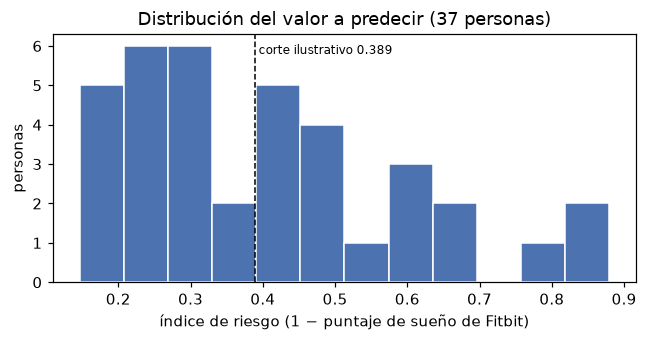

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(risk, bins=12, color="#4C72B0", edgecolor="white")
ax.axvline(risk_cut_poc1, color="k", ls="--", lw=1)
ax.text(risk_cut_poc1, ax.get_ylim()[1] * 0.92, f" corte ilustrativo {risk_cut_poc1:.3f}", fontsize=8)
ax.set_xlabel("índice de riesgo (1 − puntaje de sueño de Fitbit)")
ax.set_ylabel("personas")
ax.set_title("Distribución del valor a predecir (37 personas)")
plt.tight_layout()
plt.show()


## Modelos y evaluación

Se predice el índice continuo con **Random Forest** (el modelo elegido en POC1, en su versión de regresión) y con una
**regresión lineal regularizada (Ridge)** como referencia simple. El baseline es un modelo que **siempre predice el
promedio**. Protocolo: 5-Fold × 20 repeticiones, con predicciones siempre sobre personas que el modelo no vio.

Métricas (más simples de leer que F1 cuando el objetivo es continuo):
- **Correlación de Spearman:** ¿ordena bien a las personas de menor a mayor riesgo? 1 = orden perfecto, 0 = sin relación.
- **Error medio absoluto (MAE):** cuánto se equivoca en promedio, en las mismas unidades del índice.
- **R²:** qué parte de la variación explica el modelo. 0 = igual que predecir el promedio; negativo = peor que eso.

In [5]:
def evaluate_regression(model_factory, X, y, n_repeats=N_REPEATS):
    preds, rows = [], []
    for r in range(n_repeats):
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE + r)
        model = model_factory(RANDOM_STATE)  # semilla fija; solo cambia el reparto de personas
        p = cross_val_predict(model, X, y, cv=kf)
        preds.append(p)
        rows.append({
            "spearman": spearmanr(y, p).correlation if np.std(p) > 0 else np.nan,
            "mae": mean_absolute_error(y, p),
            "r2": r2_score(y, p),
        })
    df_r = pd.DataFrame(rows)
    return {"mean": df_r.mean(), "std": df_r.std(ddof=0)}, np.array(preds)


factories = {
    "Random Forest": lambda seed: RandomForestRegressor(n_estimators=300, max_depth=5, random_state=seed),
    "Ridge (lineal)": lambda seed: make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Baseline: siempre el promedio": lambda seed: DummyRegressor(strategy="mean"),
}

results, all_preds = {}, {}
for name, f in factories.items():
    results[name], all_preds[name] = evaluate_regression(f, X, risk)


def cell(stats, m, baseline=False):
    if baseline and m == "spearman":
        return "— (sin información)"
    return f"{stats['mean'][m]:.3f} ± {stats['std'][m]:.3f}"


table = pd.DataFrame({
    name: {"Spearman": cell(s, "spearman", baseline=name.startswith("Baseline")),
           "MAE": cell(s, "mae"), "R²": cell(s, "r2")}
    for name, s in results.items()
}).T
print(f"Referencia: desviación estándar del índice = {risk.std():.3f}")
table


Referencia: desviación estándar del índice = 0.198


,Spearman,MAE,R²
Random Forest,0.697 ± 0.050,0.108 ± 0.005,0.449 ± 0.054
Ridge (lineal),0.709 ± 0.038,0.131 ± 0.010,0.227 ± 0.127
Baseline: siempre el promedio,— (sin información),0.165 ± 0.004,-0.069 ± 0.047


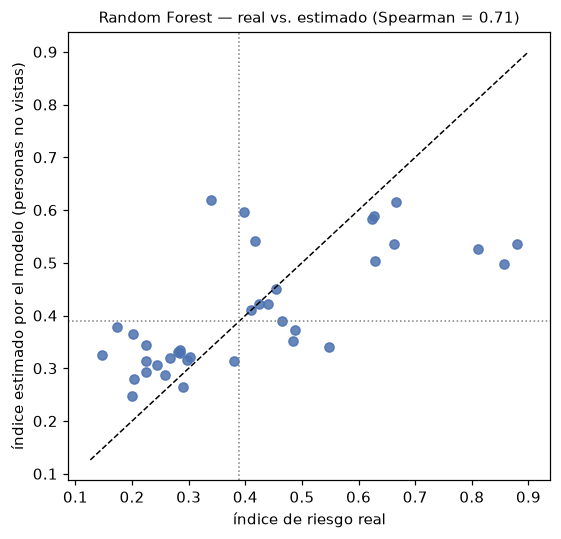

In [6]:
rf_pred = all_preds["Random Forest"].mean(axis=0)  # promedio de las 20 repeticiones (cada una sobre personas no vistas)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(risk, rf_pred, color="#4C72B0", s=36, alpha=0.85)
lims = [min(risk.min(), rf_pred.min()) - 0.02, max(risk.max(), rf_pred.max()) + 0.02]
ax.plot(lims, lims, color="k", ls="--", lw=1)
ax.axhline(risk_cut_poc1, color="grey", ls=":", lw=1)
ax.axvline(risk_cut_poc1, color="grey", ls=":", lw=1)
rho = spearmanr(risk, rf_pred).correlation
ax.set_xlabel("índice de riesgo real")
ax.set_ylabel("índice estimado por el modelo (personas no vistas)")
ax.set_title(f"Random Forest — real vs. estimado (Spearman = {rho:.2f})", fontsize=10)
plt.tight_layout()
plt.show()


## Del puntaje al riesgo: un solo modelo, cualquier corte

Aquí está la ventaja frente al percentil. Como el modelo entrega un puntaje, el "riesgo alto" se define **después**, con
el corte que corresponda. Para mostrar que la predicción sirve aunque cambie la proporción de casos, se prueban varios
cortes: el de POC1 (solo ilustrativo) y otros que dejan entre 20% y 80% de personas en riesgo alto.

Se mide con **ROC-AUC** (0.5 = azar, no depende de la prevalencia) y **PR-AUC** (su azar es igual a la prevalencia).
No se usa F1 porque con prevalencia alta un modelo tonto que siempre dice "riesgo alto" ya lo saca alto.

*Los cortes de esta tabla salen de la propia muestra solo para variar la prevalencia; no son un estándar. En el sistema
final el corte será el del instrumento elegido.*

,Corte,valor,riesgo alto,prevalencia,ROC-AUC,PR-AUC (azar)
0,Corte de POC1 (ilustrativo),0.389,18,49%,0.911 ± 0.023,0.861 ± 0.033 (0.49)
1,Corte con ~20% en riesgo alto,0.609,8,22%,0.926 ± 0.022,0.691 ± 0.074 (0.22)
2,Corte con ~35% en riesgo alto,0.446,13,35%,0.823 ± 0.031,0.662 ± 0.049 (0.35)
3,Corte con ~50% en riesgo alto,0.380,19,51%,0.885 ± 0.028,0.852 ± 0.032 (0.51)
4,Corte con ~65% en riesgo alto,0.285,24,65%,0.848 ± 0.037,0.929 ± 0.018 (0.65)
5,Corte con ~80% en riesgo alto,0.229,29,78%,0.788 ± 0.035,0.939 ± 0.012 (0.78)


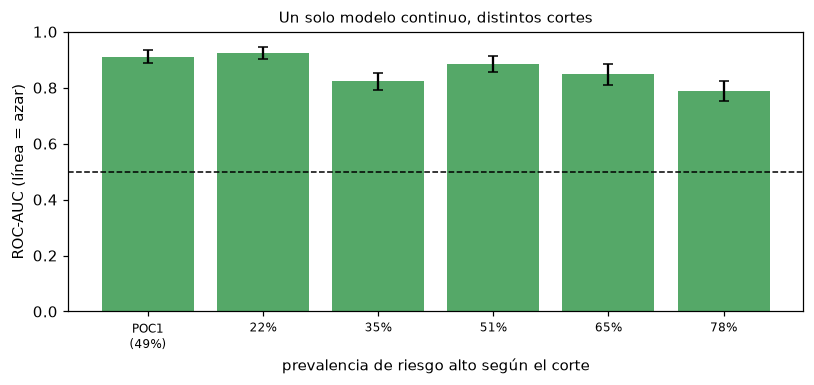

In [7]:
def cutoff_table(y, all_p):
    cuts = [("Corte de POC1 (ilustrativo)", risk_cut_poc1)]
    for p in [0.20, 0.35, 0.50, 0.65, 0.80]:
        cuts.append((f"Corte con ~{int(p*100)}% en riesgo alto", float(y.quantile(1 - p))))
    rows = []
    for label, cut in cuts:
        yb = (y >= cut).astype(int)
        rocs = [roc_auc_score(yb, p) for p in all_p]
        prs = [average_precision_score(yb, p) for p in all_p]
        rows.append({
            "Corte": label, "valor": round(cut, 3), "riesgo alto": int(yb.sum()),
            "prevalencia": f"{yb.mean():.0%}",
            "ROC-AUC": f"{np.mean(rocs):.3f} ± {np.std(rocs):.3f}",
            "PR-AUC (azar)": f"{np.mean(prs):.3f} ± {np.std(prs):.3f} ({yb.mean():.2f})",
            "_roc": np.mean(rocs), "_roc_sd": np.std(rocs),
        })
    return pd.DataFrame(rows)


ct = cutoff_table(risk, all_preds["Random Forest"])
display(ct.drop(columns=["_roc", "_roc_sd"]))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(range(len(ct)), ct["_roc"], yerr=ct["_roc_sd"], capsize=3, color="#55A868")
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_xticks(range(len(ct)))
ax.set_xticklabels([f"POC1\n({r})" if i == 0 else r for i, r in enumerate(ct["prevalencia"])], fontsize=8)
ax.set_xlabel("prevalencia de riesgo alto según el corte")
ax.set_ylabel("ROC-AUC (línea = azar)")
ax.set_ylim(0, 1)
ax.set_title("Un solo modelo continuo, distintos cortes", fontsize=10)
plt.tight_layout()
plt.show()


## Cómo se vería la salida de ML1 en la app

Para tres personas (la de mayor riesgo estimado, la más cercana al corte y la de menor riesgo) se arma la salida que
recibiría la app y el LLM. Los valores salen de predicciones sobre **personas que el modelo no vio** (como si fueran
usuarios nuevos).

- **`estimated_range_90`:** rango de incertidumbre. Se obtiene sumando al estimado los errores pasados del modelo
  (percentiles 5 y 95 de los residuos).
- **`probability_above_cutoff`:** fracción de esos errores pasados que llevaría el valor real por encima del corte.
- **`grey_zone`:** `true` si el corte cae dentro del rango, o sea que el modelo no puede decidir con seguridad.
- **`data_quality`:** noches con dato de sueño y variables sin ningún dato para esa persona.

El corte usado aquí es el ilustrativo de POC1.

In [8]:
resid = risk.values - rf_pred
q05, q95 = np.quantile(resid, [0.05, 0.95])

# importancia de variables: promedio de 20 ajustes del Random Forest con distinta semilla
imp = np.zeros(X.shape[1])
for r in range(N_REPEATS):
    m = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=RANDOM_STATE + r).fit(X, risk)
    imp += m.feature_importances_
imp = pd.Series(imp / N_REPEATS, index=X.columns).sort_values(ascending=False)
top_factors = [{"feature": f, "importance": round(float(v), 4)} for f, v in imp.head(5).items()]

ids = person_37[COL_ID].reset_index(drop=True)
grp = raw_37.groupby(COL_ID)
nights = grp["minutesAsleep"].count()
missing_vars = {pid: [v for v in PREDICTOR_VARS if g[v].notna().sum() == 0] for pid, g in grp}


def payload(i):
    est = float(rf_pred[i])
    lo, hi = float(np.clip(est + q05, 0, 1)), float(np.clip(est + q95, 0, 1))
    prob = float(np.mean(est + resid >= risk_cut_poc1))
    return {
        "student_id": ids[i],
        "estimated_risk_index": round(est, 3),
        "estimated_range_90": [round(lo, 3), round(hi, 3)],
        "cutoff_illustrative": round(risk_cut_poc1, 3),
        "probability_above_cutoff": round(prob, 2),
        "risk_level": "alto" if est >= risk_cut_poc1 else "bajo",
        "grey_zone": bool(lo <= risk_cut_poc1 <= hi),
        "top_factors": top_factors,
        "data_quality": {"nights_with_sleep_data": int(nights[ids[i]]), "missing_variables": missing_vars[ids[i]]},
    }


examples = {
    "Mayor riesgo estimado": int(np.argmax(rf_pred)),
    "Más cercana al corte": int(np.argmin(np.abs(rf_pred - risk_cut_poc1))),
    "Menor riesgo estimado": int(np.argmin(rf_pred)),
}
print(f"Errores pasados del modelo: percentil 5 = {q05:+.3f} | percentil 95 = {q95:+.3f}\n")
for title, i in examples.items():
    p = payload(i)
    p_short = {k: v for k, v in p.items() if k != "top_factors"}
    print(f"### {title}")
    print(json.dumps(p_short, indent=2, ensure_ascii=False))
    print()
print("top_factors (iguales para todas):")
print(json.dumps(top_factors, indent=2, ensure_ascii=False))


Errores pasados del modelo: percentil 5 = -0.200 | percentil 95 = +0.296

### Mayor riesgo estimado
{
  "student_id": "621e328667b776a240281372",
  "estimated_risk_index": 0.62,
  "estimated_range_90": [
    0.42,
    0.916
  ],
  "cutoff_illustrative": 0.389,
  "probability_above_cutoff": 0.97,
  "risk_level": "alto",
  "grey_zone": false,
  "data_quality": {
    "nights_with_sleep_data": 6,
    "missing_variables": [
      "spo2"
    ]
  }
}

### Más cercana al corte
{
  "student_id": "621e2f6167b776a240e082a9",
  "estimated_risk_index": 0.39,
  "estimated_range_90": [
    0.191,
    0.687
  ],
  "cutoff_illustrative": 0.389,
  "probability_above_cutoff": 0.49,
  "risk_level": "alto",
  "grey_zone": true,
  "data_quality": {
    "nights_with_sleep_data": 45,
    "missing_variables": []
  }
}

### Menor riesgo estimado
{
  "student_id": "621e2f9167b776a240011ccb",
  "estimated_risk_index": 0.248,
  "estimated_range_90": [
    0.048,
    0.544
  ],
  "cutoff_illustrative": 0.389,
  "pr

## Extra: columnas de etapas de sueño que existen en el CSV y no se usan

El CSV trae columnas de etapas de sueño (`sleep_deep_ratio`, `sleep_light_ratio`, `sleep_rem_ratio`, `sleep_wake_ratio`).
No forman parte de las 22 features de POC1. Su cobertura:

**Ojo con su significado:** las cuatro promedian ≈ 1, lo que indica que son **razones relativas** (posiblemente contra un
valor de referencia) y no proporciones de la noche. Su definición no está documentada aquí; hay que confirmarla antes de
usarlas como variables.

In [9]:
rows = []
for c in STAGE_COLS:
    ok = raw_df[c].notna()
    rows.append({"Variable": c, "Filas con dato": int(ok.sum()),
                 "% de las 7,410 filas": f"{ok.mean():.0%}",
                 "Personas": int(raw_df.loc[ok, COL_ID].nunique()),
                 "Media": round(float(raw_df[c].mean()), 3)})
pd.DataFrame(rows)


,Variable,Filas con dato,"% de las 7,410 filas",Personas,Media
0,sleep_deep_ratio,3294,44%,61,1.004
1,sleep_light_ratio,3294,44%,61,0.994
2,sleep_rem_ratio,3294,44%,61,1.008
3,sleep_wake_ratio,3294,44%,61,0.997


## Lectura de los resultados

**Predecir un puntaje continuo funciona con este proxy.**
- Random Forest: correlación de Spearman **0.70**, error medio (MAE) **0.108** frente a 0.165 del baseline que siempre
  predice el promedio (35% menos error), y R² **0.45** frente a −0.07 del baseline.
- Ridge ordena igual de bien (Spearman 0.71) pero se equivoca más (MAE 0.131, R² 0.23): Random Forest sigue siendo la
  mejor opción y es el modelo elegido.

**Un solo modelo sirve para cualquier corte.** Con cortes que dejan entre 22% y 78% de personas en riesgo alto, el
ROC-AUC va de 0.79 a 0.93 y el PR-AUC queda muy por encima del azar en todos. Con el percentil, la prevalencia estaría
fijada en 25% por construcción.

**Límites que este ensayo deja a la vista:**
- **La incertidumbre es grande.** Los errores pasados van de −0.20 a +0.30 con una desviación estándar del índice de
  0.198, así que el rango de 90% es ancho y dos de las tres personas de ejemplo caen en "zona gris".
- **El rango es el mismo para todas las personas.** No se ensancha para quien tiene pocas noches: la persona de mayor
  riesgo estimado tiene solo 6 noches con dato de sueño. Mejorarlo (rangos que dependan de la calidad de los datos, o un
  mínimo de noches) queda como trabajo pendiente.
- **El ranking de variables es global, no por persona,** y con 37 personas es inestable: aquí `sedentary_minutes_mean`
  domina (0.53), distinto del ranking de POC1. No debe citarse como hallazgo.
- Sigue siendo un proxy y n=37: se ensaya el **diseño**, no el desempeño final.

## Notas metodológicas

- Mismo protocolo de repetición que POC1 (5-Fold × 20, semilla 42), sin estratificar porque el objetivo es continuo.
- Con 37 personas los resultados son ruidosos; la desviación estándar solo refleja el reparto de personas en los
  pliegues, no la incertidumbre de haber medido solo a 37.
- El objetivo sigue siendo un proxy (puntaje de sueño de Fitbit). Este notebook ensaya el **diseño** (puntaje continuo +
  corte fijo + rango + calidad de datos), no el desempeño final.
- Los cortes de la tabla se derivan de la muestra solo para variar la prevalencia; no son un estándar clínico.
